# UMAP Chemical Space Visualisation with PubChemLite

This notebook projects a large chemical reference set (PubChemLite 10 %) and two
smaller compound collections onto a shared 2-D UMAP embedding derived from
SIRIUS fingerprints.  The resulting scatter plot shows where the smaller sets
sit within the broader chemical space.

**Datasets**

| File | Description |
|---|---|
| `PubChemLite_10_percent.tsv` | 10 % random sample of PubChemLite; provides the reference chemical space |
| `BV10_regression_set.tsv`    | Dataset for the BV10 regression modeling worklfow |
| `RE_classification_set.tsv`  | Dataset for the RE classification modeling workflow |

**Workflow**

1. Load datasets  
2. Convert SIRIUS fingerprints to dense bit-vector arrays  
3. Fit a UMAP model on PubChemLite; project the smaller sets into that space  
4. Identify unique chemicals and label them by source dataset  
5. Visualise the embedding  


In [1]:
# Standard scientific-computing stack
import pandas as pd
import numpy as np

# RDKit — cheminformatics; used for bit-vector conversion
import rdkit
from rdkit import Chem, DataStructs
from rdkit.DataStructs.cDataStructs import ExplicitBitVect, ConvertToNumpyArray

# UMAP dimensionality-reduction
import umap

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt


## Helper Functions


In [2]:
def to_list_of_ints(fp_string: str) -> list[int]:
    """
    Parse a SIRIUS fingerprint string into a list of integer indices.

    The fingerprint is stored as a string of the form "[idx1, idx2, ...]"
    where each index marks a set bit in the original bit-vector.

    Parameters
    ----------
    fp_string : str
        Raw fingerprint string, e.g. "[0, 7, 42, ...]"

    Returns
    -------
    list[int]
        Sorted list of bit indices.
    """
    return [int(e) for e in fp_string[1:-1].split(",")]


def indices_to_bitvect_array(indices: list[int], size: int = 5000) -> np.ndarray:
    """
    Convert a list of set-bit indices into a dense NumPy array.

    Uses RDKit's ``ExplicitBitVect`` as an intermediate representation so that
    the resulting array is compatible with UMAP's input expectations.

    Parameters
    ----------
    indices : list[int]
        Indices of bits that are set (1) in the fingerprint.
    size : int, optional
        Total length of the bit-vector (default 5000).

    Returns
    -------
    np.ndarray, shape (size,), dtype int
        Binary array with 1s at the given indices.

    Raises
    ------
    ValueError
        If any index is outside [0, size).
    """
    bv = ExplicitBitVect(size)
    for idx in indices:
        if 0 <= idx < size:
            bv.SetBit(idx)
        else:
            raise ValueError(
                f"Bit index {idx} is out of range for a {size}-bit vector."
            )
    arr = np.zeros((size,), dtype=int)
    ConvertToNumpyArray(bv, arr)
    return arr


def get_source_label(
    smiles: str,
    bv10_smiles: set[str],
    re_smiles: set[str],
) -> str:
    """
    Return a human-readable source label for a compound given its SMILES.

    Parameters
    ----------
    smiles : str
        Canonical SMILES string identifying the compound.
    bv10_smiles : set[str]
        SMILES present in the BV10 regression set.
    re_smiles : set[str]
        SMILES present in the RE classification set.

    Returns
    -------
    str
        One of ``'Both'``, ``'BV10 regressor set'``, or ``'RE classifier set'``.
    """
    in_bv10 = smiles in bv10_smiles
    in_re   = smiles in re_smiles

    if in_bv10 and in_re:
        return "Both"
    elif in_bv10:
        return "BV10 regressor set"
    else:
        return "RE classifier set"


def project_dataset(df: pd.DataFrame, fp_col: str, mapper: umap.UMAP) -> pd.DataFrame:
    """
    Project a dataset into a pre-fitted UMAP embedding space.

    Adds ``x_axis`` and ``y_axis`` columns to *df* in-place and also returns it.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the fingerprint column.
    fp_col : str
        Name of the column that holds the dense fingerprint arrays.
    mapper : umap.UMAP
        A fitted UMAP model (produced by ``umap.UMAP().fit(…)``).

    Returns
    -------
    pd.DataFrame
        The input DataFrame with ``x_axis`` and ``y_axis`` columns appended.
    """
    coords = mapper.transform(list(df[fp_col]))
    df[["x_axis", "y_axis"]] = coords
    return df


## 1. Load Datasets

> **Note:** Set `low_memory=False` on `RE_classification_set` to suppress the
> mixed-type dtype warning for columns 3 and 4.


In [3]:
PCL_01               = pd.read_csv("PubChemLite_10_percent.tsv",  sep="\t")
BV10_regression_set  = pd.read_csv("BV10_regression_set_for_mapping.tsv",      sep="\t")
RE_classification_set = pd.read_csv(
    "RE_classification_set_for_mapping.tsv", sep="\t", low_memory=False
)

print("PubChemLite rows:",         len(PCL_01))
print("BV10 regression rows:",     len(BV10_regression_set))
print("RE classification rows:",   len(RE_classification_set))


PubChemLite rows: 56578
BV10 regression rows: 413
RE classification rows: 146


## 2. Convert Fingerprints to Dense Arrays

### 2a. PubChemLite

PubChemLite stores SIRIUS fingerprints as a *relative* (sparse index) string in
the `SIRIUS_fp_rel` column.  We parse those indices and expand them into a dense
5000-bit NumPy array per compound.


In [4]:
# Step 1: parse the index string → list of integers
PCL_01["SIRIUS_fp_rel"] = PCL_01["SIRIUS_fp_rel"].apply(to_list_of_ints)

# Step 2: expand indices → dense 5000-bit array
PCL_01["SIRIUS_fp_bitvect"] = PCL_01["SIRIUS_fp_rel"].apply(indices_to_bitvect_array)


### 2b. BV10 Regression Set and RE Classification Set

In these datasets the fingerprint bits are already stored as individual columns
(one column per bit position) rather than as a sparse index string.  We
concatenate those columns into a single array column for each row.

* **BV10 regression set**: fingerprint bits start at column index 21  
* **RE classification set**: fingerprint bits start at column index 6  


In [7]:
# BV10 regression set — fingerprint bits begin at column 21
BV10_regression_set["SIRIUS_fp_bitvect"] = [
    BV10_regression_set.iloc[i, 21:].values
    for i in range(len(BV10_regression_set))
]

# RE classification set — fingerprint bits begin at column 6
RE_classification_set["SIRIUS_fp_bitvect"] = [
    RE_classification_set.iloc[i, 6:].values
    for i in range(len(RE_classification_set))
]


## 3. Fit UMAP on PubChemLite and Project Smaller Sets

We fit a UMAP model on the PubChemLite 10 % sample to define the reference
chemical space, then *project* (transform) the smaller sets into that same
2-D space so all three can be compared on a common coordinate system.

**UMAP hyper-parameters**

| Parameter | Value | Rationale |
|---|---|---|
| `n_neighbors` | 20 | Controls the local vs. global structure trade-off; 20 balances both |
| `min_dist` | 0.5 | Larger values spread points out more, aiding visual separation |


In [10]:
# ── Fit UMAP on PubChemLite ────────────────────────────────────────────────
mapper = umap.UMAP(n_neighbors=20, min_dist=0.5).fit(
    list(PCL_01["SIRIUS_fp_bitvect"])
)

# Store the training-set coordinates directly from the fitted model
PCL_01["x_axis"] = mapper.embedding_[:, 0]
PCL_01["y_axis"] = mapper.embedding_[:, 1]


# ── Project the smaller sets into the same embedding space ────────────────
project_dataset(BV10_regression_set,  "SIRIUS_fp_bitvect", mapper)
project_dataset(RE_classification_set, "SIRIUS_fp_bitvect", mapper)


,source,water_type,Name,RE (%),DOC (mg/L),SMILES,8,21,33,34,...,17990,18006,18008,18013,18015,18018,18023,SIRIUS_fp_bitvect,x_axis,y_axis
0,6,WW,"10,11-Dihydroxycarbamazepine",100,10.1,C1=CC=C2C(=C1)C(C(C3=CC=CC=C3N2C(=O)N)O)O,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, ...",-3.046541,0.991712
1,6,WW,Sulfamethoxazole,100,10.1,CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",-6.189255,1.062604
2,6,WW,Erythromycin,100,10.1,CCC1C(C(C(C(=O)C(CC(C(C(C(C(C(=O)O1)C)OC2CC(C(...,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, ...",1.442434,9.230915
3,6,WW,Gabapentin,21,10.1,C1CCC(CC1)(CC(=O)O)CN,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...",2.898489,1.213135
4,6,WW,Caffeine,100,10.1,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",-7.678478,7.486472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,37,DW,PFTeDA,90,1.8,C(=O)(C(C(C(C(C(C(C(C(C(C(C(C(C(F)(F)F)(F)F)(F...,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.538868,1.491682
142,37,DW,PFBS,100,1.8,C(C(C(F)(F)S(=O)(=O)O)(F)F)(C(F)(F)F)(F)F,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.585734,0.624809
143,37,DW,PFHxS,100,1.8,C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(C(C(F)(F)F)...,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.651055,0.798628
144,37,DW,PFOS,100,1.8,C(C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(F)F)(C(C(...,0,0,0,0,...,0,0,0,0,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.721143,0.897882


## 4. Identify Unique Chemicals and Assign Source Labels

Some compounds appear in both the BV10 and RE sets.  We deduplicate by SMILES
and assign a `source` label to track their origin.


In [14]:
# Keep only the columns needed for visualisation
_cols = ["Name", "SMILES", "SIRIUS_fp_bitvect", "x_axis", "y_axis"]

BV10_unique = (
    BV10_regression_set[_cols]
    .drop_duplicates(subset="SMILES", ignore_index=True)
)
RE_unique = (
    RE_classification_set[_cols]
    .drop_duplicates(subset="SMILES", ignore_index=True)
)

# Merge both sets, then de-duplicate again across the combined pool
all_unique_chems = (
    pd.concat([BV10_unique, RE_unique], ignore_index=True)
    .drop_duplicates(subset="SMILES", ignore_index=True)
)

# Build lookup sets for efficient membership testing
bv10_smiles_set = set(BV10_unique["SMILES"])
re_smiles_set   = set(RE_unique["SMILES"])

# Assign source label to each unique compound
all_unique_chems["source"] = all_unique_chems["SMILES"].apply(
    lambda s: get_source_label(s, bv10_smiles_set, re_smiles_set)
)

print(f"Unique compounds: {len(all_unique_chems)}")
print(all_unique_chems["source"].value_counts())
all_unique_chems.head()


Unique compounds: 95
source
RE classifier set     52
BV10 regressor set    24
Both                  19
Name: count, dtype: int64


,Name,SMILES,SIRIUS_fp_bitvect,x_axis,y_axis,source
0,Carbamazepine,C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2C(=O)N,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",-3.429541,1.377981,Both
1,Diatrizoic acid,CC(=O)NC1=C(C(=C(C(=C1I)C(=O)O)I)NC(=O)C)I,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",-4.469894,1.178063,Both
2,Diclofenac,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",-2.221769,-0.632703,Both
3,Iomeprol,CN(C1=C(C(=C(C(=C1I)C(=O)NCC(CO)O)I)C(=O)NCC(C...,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, ...",-4.269392,0.781410,Both
4,Iopromide,CN(CC(CO)O)C(=O)C1=C(C(=C(C(=C1I)C(=O)NCC(CO)O...,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, ...",-4.382735,1.096369,Both


## 5. Visualise the Chemical Space

The grey background layer represents the full PubChemLite reference space.
Coloured points on top indicate where the smaller compound sets land within
that reference space.

| Colour | Dataset |
|---|---|
| Grey (#ccc9c9) | PubChemLite 10 % (reference) |
| Pink (#EB006E) | BV10 regressor set only |
| Blue (#0471D6) | RE classifier set only |
| Yellow (#FFD900) | Present in both sets |


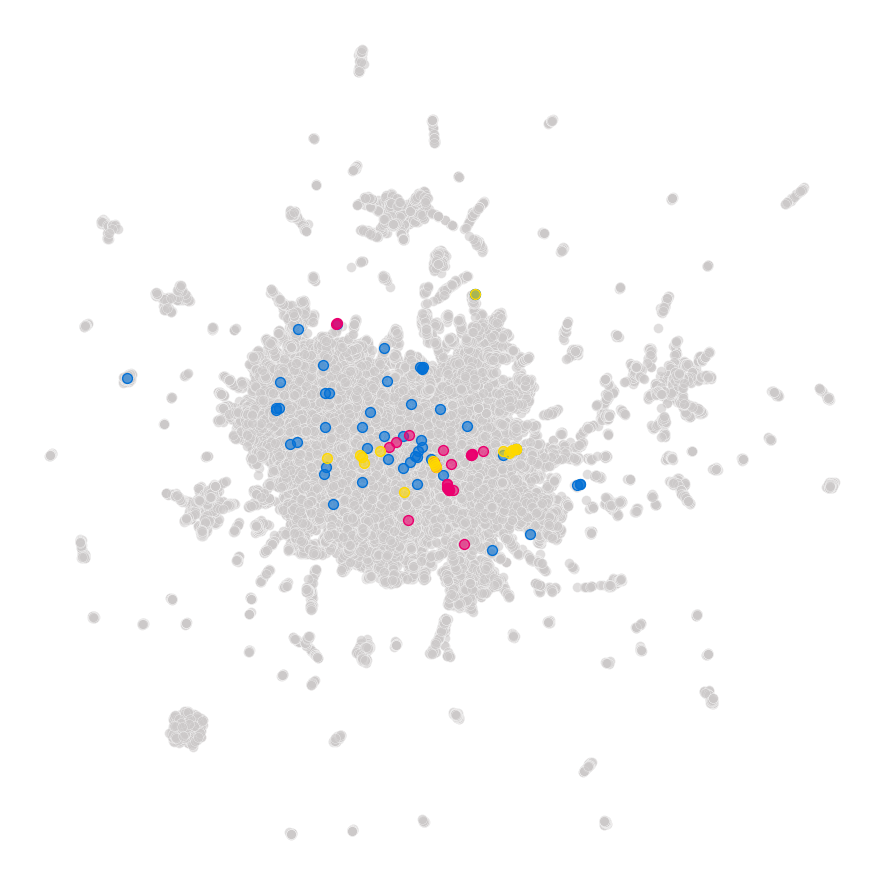

In [15]:
# ── Plot configuration ─────────────────────────────────────────────────────
COLORMAP = {
    "BV10 regressor set": "#EB006E",
    "RE classifier set":  "#0471D6",
    "Both":               "#FFD900",
}
# Render 'Both' last so yellow dots appear on top of pink/blue
PLOT_ORDER = ["RE classifier set", "BV10 regressor set", "Both"]

sns.set(font_scale=1)
sns.set_style("white")

fig, ax = plt.subplots(figsize=(9, 9))

# ── Layer 1: PubChemLite reference space (grey background) ────────────────
sns.scatterplot(
    x=PCL_01["x_axis"],
    y=PCL_01["y_axis"],
    s=50, alpha=0.6, color="#ccc9c9",
    ax=ax,
)

# ── Layer 2: smaller sets coloured by source ──────────────────────────────
for source in PLOT_ORDER:
    subset = all_unique_chems[all_unique_chems["source"] == source]
    sns.scatterplot(
        x=subset["x_axis"],
        y=subset["y_axis"],
        s=50, alpha=0.6,
        label=source,
        c=COLORMAP[source],
        ax=ax,
    )

# ── Post-processing: opaque edges for crisp point boundaries ──────────────
for collection in ax.collections:
    fc = collection.get_facecolors().copy()
    ec = fc.copy()
    ec[:, -1] = 1       # edge alpha = 1 (fully opaque)
    fc[:, -1] = 0.6     # face alpha = 0.6 (semi-transparent)
    collection.set_facecolors(fc)
    collection.set_edgecolors(ec)
    collection.set_linewidth(1)
    collection.set_alpha(None)  # disable per-collection alpha override

# Soften edges on the grey background layer
ax.collections[0].set_edgecolor("white")
ax.collections[0].set_linewidth(0.2)

# Clean up axes and legend
ax.set_axis_off()
ax.get_legend().remove()

plt.tight_layout()
plt.savefig("umap_chemical_space.png", dpi=300, bbox_inches="tight")
plt.show()
